In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Cargamos los datos y dividimos en train y test.
airbnb = pd.read_csv("C:/Users/ferna/Desktop/Machine-Learning-101/Proyecto/Proyecto/airbnb-listings-extract.csv", sep=";")
train, test = train_test_split(airbnb, test_size=0.2, shuffle=True, random_state=0)

# Guardamos
train.to_csv("C:/Users/ferna/Desktop/Machine-Learning-101/Proyecto/Proyecto/airbnb-listings-extract-train.csv", sep=';', decimal='.', index=False)
test.to_csv("C:/Users/ferna/Desktop/Machine-Learning-101/Proyecto/Proyecto/airbnb-listings-extract-test.csv", sep=';', decimal='.', index=False)

# Cargarmos datos de train
house_data_train = pd.read_csv("C:/Users/ferna/Desktop/Machine-Learning-101/Proyecto/Proyecto/airbnb-listings-extract-train.csv", sep=';', decimal='.')
house_data_train.head()

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,5994463,https://www.airbnb.com/rooms/5994463,20170407214119,2017-04-08,PISO ATOCHA- FLAT NEAR ATOCHA .,Piso recién reformado cómoda habitación con ba...,"Un piso muy cómodo en Jerónimos, una de las zo...",Piso recién reformado cómoda habitación con ba...,none,El barrio de Jeronimos es un enclave tranquilo...,...,10.0,10.0,9.0,NaN,NaN,moderate,2.0,0.50,"40.4077318793,-3.68481869733","Host Has Profile Pic,Is Location Exact,Require..."
1,14136180,https://www.airbnb.com/rooms/14136180,20170407214119,2017-04-08,The Palace Sol Madrid.,"Lugares de interés: Plaza Mayor, Plaza del Sol...",El apartamento dispone de un dormitorio indepe...,"Lugares de interés: Plaza Mayor, Plaza del Sol...",none,"Situado en el corazón de Madrid, este apartame...",...,10.0,10.0,10.0,NaN,NaN,flexible,1.0,2.43,"40.4158022422,-3.70534037765","Host Has Profile Pic,Host Identity Verified,Re..."
2,15520134,https://www.airbnb.com/rooms/15520134,20170407214119,2017-04-08,por persona la noche metro linea5 vista alegre,"我的房源靠近餐厅和餐饮、适合家庭的活动、公共交通。因为舒适的床、温馨、厨房、景观,您一定会爱...",NaN,"我的房源靠近餐厅和餐饮、适合家庭的活动、公共交通。因为舒适的床、温馨、厨房、景观,您一定会爱...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,moderate,16.0,NaN,"40.3890481626,-3.74037392557","Host Has Profile Pic,Host Identity Verified,Is..."
3,8809721,https://www.airbnb.com/rooms/8809721,20170407214119,2017-04-08,CITY CENTER JACINTO BENAVENTE ROOM4,This stunning and amazig room is covered with ...,NaN,This stunning and amazig room is covered with ...,none,NaN,...,NaN,NaN,NaN,NaN,NaN,strict,97.0,NaN,"40.4128140929,-3.70305247638","Host Has Profile Pic,Requires License"
4,1162707,https://www.airbnb.com/rooms/1162707,20170407214119,2017-04-08,NICE & BIG DOUBLE ROOM AT DOWNTOWN,NaN,We are a young couple; David (Spain) and Ana (...,We are a young couple; David (Spain) and Ana (...,none,NaN,...,10.0,9.0,9.0,NaN,NaN,strict,2.0,2.08,"40.4386311984,-3.71371613279","Host Has Profile Pic,Host Identity Verified,Is..."


In [2]:
house_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11824 entries, 0 to 11823
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              11824 non-null  int64  
 1   Listing Url                     11824 non-null  object 
 2   Scrape ID                       11824 non-null  int64  
 3   Last Scraped                    11824 non-null  object 
 4   Name                            11823 non-null  object 
 5   Summary                         11355 non-null  object 
 6   Space                           8718 non-null   object 
 7   Description                     11818 non-null  object 
 8   Experiences Offered             11824 non-null  object 
 9   Neighborhood Overview           7309 non-null   object 
 10  Notes                           4543 non-null   object 
 11  Transit                         7243 non-null   object 
 12  Access                          

In [3]:
# Compruebo sí hay precios con valores nulos:
house_data_train["Price"].isna().sum()

np.int64(15)

In [4]:
# Tras analizar las columnas del dataset, hago una primera limpieza de columnas irrelevantes:
house_data_train = house_data_train.drop(columns = [
    "ID","Scrape ID","Host ID","Listing Url","Thumbnail Url",
    "Medium Url","Picture Url","XL Picture Url","Host URL","Host Thumbnail Url",
    "Host Picture Url","Name","Summary","Space","Description","Neighborhood Overview",
    "Notes","Transit","Access","Interaction","House Rules","Host About",
    "Features","Square Feet","Weekly Price","Monthly Price","License","Jurisdiction Names",
    "Has Availability","Host Acceptance Rate","Geolocation","Smart Location",
    "Last Scraped","Calendar last Scraped","Calendar Updated"])

# Elimino columnas importantes como 'Square Feet' por contener muchos datos nulos.

In [5]:
# TRABAJO SOBRE LOS DATOS DE TRAIN:

# Eliminamos las filas con precios nulos:
house_data_train = house_data_train.dropna(subset=["Price"])

# TargetEncoder de columna 'City','Neighbourhood Cleansed','Room Type','Bed Type':
categorical = ['City','Neighbourhood Cleansed','Room Type','Bed Type']

mean_map = {}
for c in categorical:
    mean = house_data_train.groupby(c)['Price'].mean()
    house_data_train[c] = house_data_train[c].map(mean)    
    mean_map[c] = mean

# Creo nuevas columnas
# Columna 'Air conditioning', extrayendo datos de 'Amenities':
house_data_train["Air conditioning"] = (
    house_data_train["Amenities"]
    .str.contains("Air conditioning" or "aire acondicionado", na=False)
    .astype(int)
)

# Columna 'pool', extrayendo datos de 'Amenities':
house_data_train["Pool"] = (
    house_data_train["Amenities"]
    .str.contains("Pool", na=False)
    .astype(int)
)

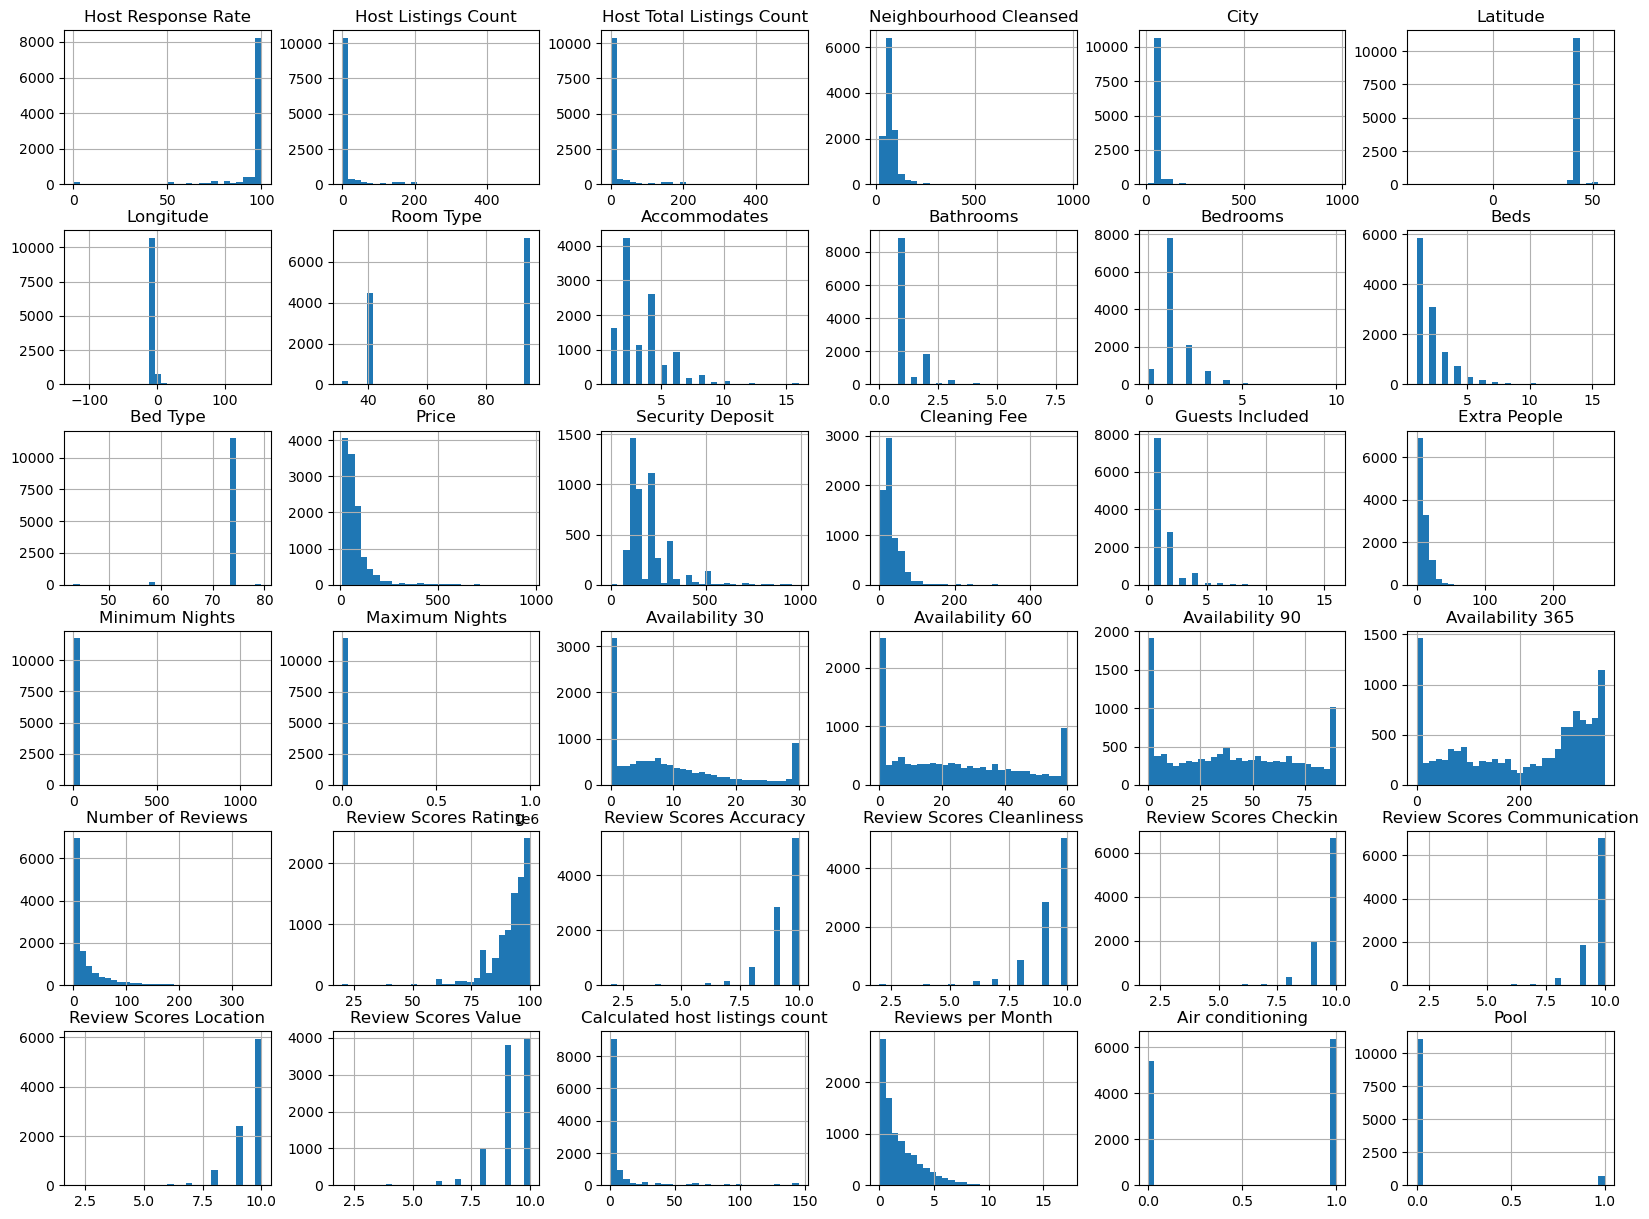

In [6]:
# Analizo las columnas con histogramas:
import matplotlib.pyplot as plt

house_data_train.hist(figsize=(20, 15), bins=30)
plt.show()

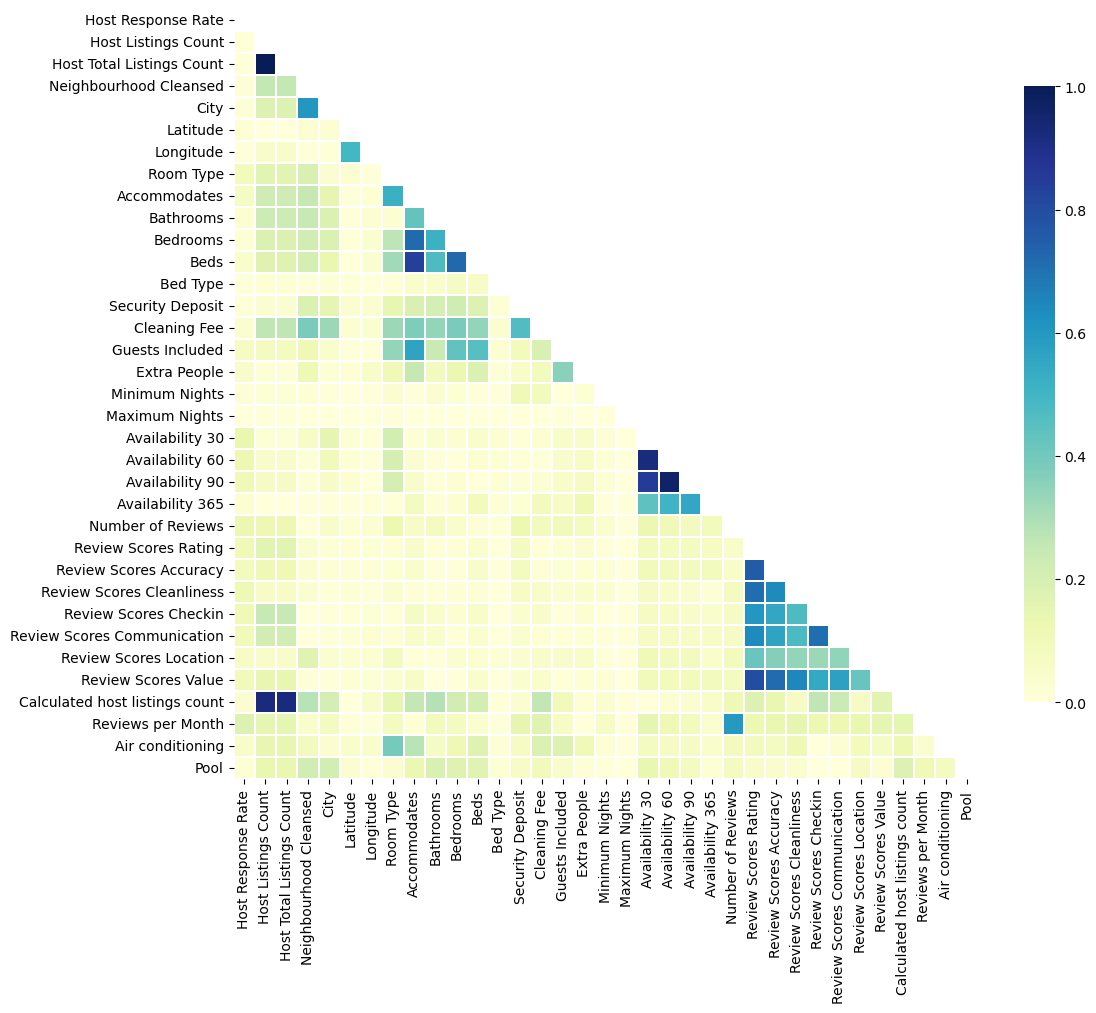

In [7]:
'''
Matriz de correlación. Nos permite ver que columnas se relacionan. Esto nos ayudará a desechar columnas con
alta correlación y así prevenir overfitting.
'''
import seaborn as sns

numeric_df = house_data_train.select_dtypes(include=[np.number])

corr = np.abs(numeric_df.drop(['Price'], axis=1).corr())

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()

In [8]:
# Elimino columnas con mayor correlación:
house_data_train = house_data_train.drop(columns = 
                                         ['Review Scores Rating', 'Availability 30','Availability 60','Availability 90',
                                         'Host Listings Count', 'Beds'])
                                         

In [9]:
# Elimino las pocas filas donde "Calculated host listings count" tiene valores nulos:
house_data_train = house_data_train.dropna(subset=["Calculated host listings count"])

In [10]:
# Continuo el analisis de las columnas de tipo "object":
house_data_train.select_dtypes(include=["object"]).columns

Index(['Experiences Offered', 'Host Name', 'Host Since', 'Host Location',
       'Host Response Time', 'Host Neighbourhood', 'Host Verifications',
       'Street', 'Neighbourhood', 'Neighbourhood Group Cleansed', 'State',
       'Zipcode', 'Market', 'Country Code', 'Country', 'Property Type',
       'Amenities', 'First Review', 'Last Review', 'Cancellation Policy'],
      dtype='object')

In [11]:
house_data_train['Property Type'].unique()

array(['Apartment', 'Loft', 'House', 'Bed & Breakfast', 'Dorm', 'Chalet',
       'Condominium', 'Guesthouse', 'Hostel', 'Other', 'Villa',
       'Boutique hotel', 'Camper/RV', 'Casa particular', 'Townhouse',
       'Serviced apartment', 'Guest suite', 'Boat', 'Tent', 'Earth House',
       'Bungalow'], dtype=object)

In [12]:
house_data_train["Property Type"].value_counts()

Property Type
Apartment             9586
House                 1081
Condominium            283
Bed & Breakfast        274
Loft                   248
Other                  171
Dorm                    37
Guesthouse              32
Chalet                  22
Townhouse               15
Villa                   13
Hostel                  13
Serviced apartment       9
Boutique hotel           5
Camper/RV                3
Casa particular          3
Boat                     3
Guest suite              2
Earth House              2
Bungalow                 2
Tent                     1
Name: count, dtype: int64

In [13]:
# Ordeno los categorias de la columna 'Property Type':
rare_types = house_data_train["Property Type"].value_counts()

rare_types = rare_types[rare_types < 50].index

house_data_train["Property Type"] = house_data_train["Property Type"].replace(
    rare_types,
    "Other"
)

In [14]:
# 'Property Type' modificada:
house_data_train["Property Type"].value_counts()

Property Type
Apartment          9586
House              1081
Other               333
Condominium         283
Bed & Breakfast     274
Loft                248
Name: count, dtype: int64

In [15]:
# Aplico One-Hot Encoding en la columna 'Property Type':
house_data_train = pd.get_dummies(
    house_data_train,
    columns=["Property Type"],
    drop_first=True,
    dtype=int
)

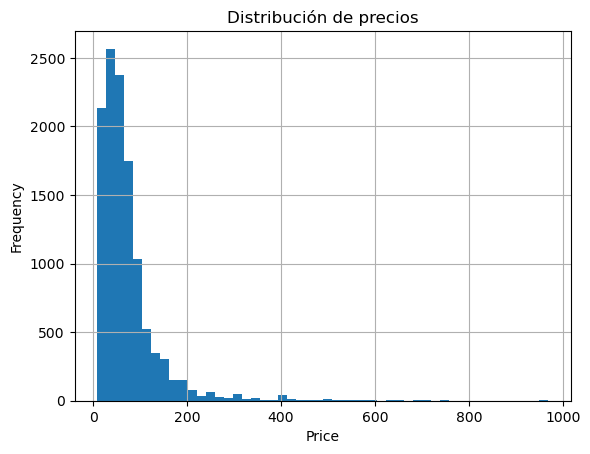

In [16]:
# Analizo la distrubución de nuestro target:
house_data_train["Price"].hist(bins=50)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribución de precios")

plt.show()

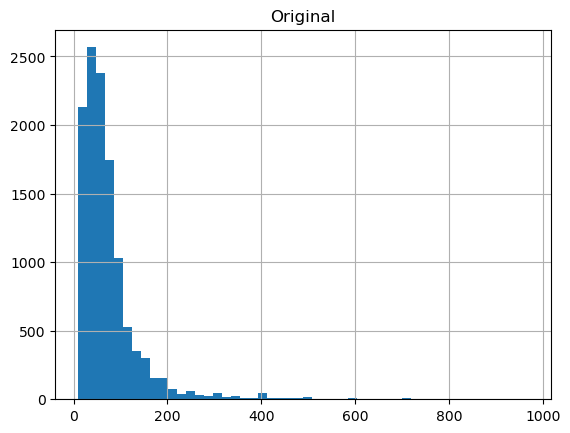

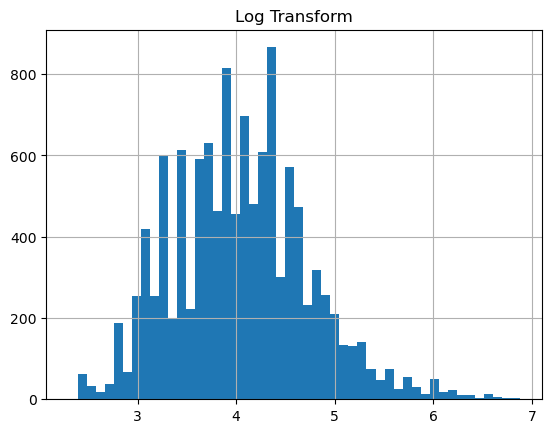

In [17]:
# Aplico una transformacion de los precios pasandolos a una escala logaritmica. Con este cambio, conseguimos
# una mejor distribución y el modelo aprenderá mejor:

# Original
house_data_train["Price"].hist(bins=50)
plt.title("Original")
plt.show()

# Log
np.log1p(house_data_train["Price"]).hist(bins=50)
plt.title("Log Transform")
plt.show()

In [18]:
# Aplico el log a la columna 'Price':
house_data_train['Price'] = np.log1p(house_data_train["Price"])

In [19]:
# Elimino el resto de columnas irrelevantes tras mi analisis:
house_data_train = house_data_train.drop(columns= ['Experiences Offered', 'Host Name', 'Host Since', 'Host Location',
       'Host Response Time', 'Host Neighbourhood', 'Host Verifications',
       'Street', 'Neighbourhood', 'Neighbourhood Group Cleansed', 'State',
       'Zipcode', 'Market', 'Country Code', 'Country', 'Amenities', 'First Review', 'Last Review', 'Cancellation Policy'])

In [20]:
# Columnas que tenemos para nuestro modelo:
house_data_train.columns

Index(['Host Response Rate', 'Host Total Listings Count',
       'Neighbourhood Cleansed', 'City', 'Latitude', 'Longitude', 'Room Type',
       'Accommodates', 'Bathrooms', 'Bedrooms', 'Bed Type', 'Price',
       'Security Deposit', 'Cleaning Fee', 'Guests Included', 'Extra People',
       'Minimum Nights', 'Maximum Nights', 'Availability 365',
       'Number of Reviews', 'Review Scores Accuracy',
       'Review Scores Cleanliness', 'Review Scores Checkin',
       'Review Scores Communication', 'Review Scores Location',
       'Review Scores Value', 'Calculated host listings count',
       'Reviews per Month', 'Air conditioning', 'Pool',
       'Property Type_Bed & Breakfast', 'Property Type_Condominium',
       'Property Type_House', 'Property Type_Loft', 'Property Type_Other'],
      dtype='object')

In [21]:
# CARGAMOS DATOS DE TEST Y APLICAMOS LOS MISMO CAMBIOS QUE HEMOS HECHO EN TRAIN:

house_data_test = pd.read_csv("C:/Users/ferna/Desktop/Machine-Learning-101/Proyecto/Proyecto/airbnb-listings-extract-test.csv", sep=';', decimal='.')

house_data_test = house_data_test.drop(columns = [
    "ID","Scrape ID","Host ID","Listing Url","Thumbnail Url",
    "Medium Url","Picture Url","XL Picture Url","Host URL","Host Thumbnail Url",
    "Host Picture Url","Name","Summary","Space","Description","Neighborhood Overview",
    "Notes","Transit","Access","Interaction","House Rules","Host About",
    "Features","Square Feet","Weekly Price","Monthly Price","License","Jurisdiction Names",
    "Has Availability","Host Acceptance Rate","Geolocation","Smart Location",
    "Last Scraped","Calendar last Scraped","Calendar Updated"])

# Eliminamos las filas con precios nulos:
house_data_test = house_data_test.dropna(subset=["Price"])

# TargetEncoder de columna 'City','Neighbourhood Cleansed','Room Type','Bed Type':
categorical = ['City','Neighbourhood Cleansed','Room Type','Bed Type']

for c in categorical:
    house_data_test[c] = house_data_test[c].map(mean_map[c])

# Creación de columnas:
house_data_test["Air conditioning"] = (
    house_data_test["Amenities"]
    .str.contains("Air conditioning" or "aire acondicionado", na=False)
    .astype(int)
)

house_data_test["Pool"] = (
    house_data_test["Amenities"]
    .str.contains("Pool", na=False)
    .astype(int)
)

house_data_test = house_data_test.drop(columns = 
                                         ['Review Scores Rating', 'Availability 30','Availability 60','Availability 90',
                                         'Host Listings Count', 'Beds'])

house_data_test = house_data_test.dropna(subset=["Calculated host listings count"])

rare_types = house_data_test["Property Type"].value_counts()

rare_types = rare_types[rare_types < 50].index

house_data_test["Property Type"] = house_data_test["Property Type"].replace(
    rare_types,
    "Other"
)

house_data_test = pd.get_dummies(
    house_data_test,
    columns=["Property Type"],
    drop_first=True,
    dtype=int
)

house_data_test['Price'] = np.log1p(house_data_test["Price"])

house_data_test = house_data_test.drop(columns= ['Experiences Offered', 'Host Name', 'Host Since', 'Host Location',
       'Host Response Time', 'Host Neighbourhood', 'Host Verifications',
       'Street', 'Neighbourhood', 'Neighbourhood Group Cleansed', 'State',
       'Zipcode', 'Market', 'Country Code', 'Country', 'Amenities', 'First Review', 'Last Review', 'Cancellation Policy'])

In [22]:
from sklearn import preprocessing

# Dataset de train
y_train = house_data_train["Price"]     # nos quedamos con la columna 'Price'
X_train = house_data_train.drop(columns="Price")      # nos quedamos con el resto

# Dataset de test
y_test = house_data_test["Price"]    # nos quedamos con la columna 'Price'
X_test = house_data_test.drop(columns="Price")      # nos quedamos con el resto

feature_names = X_train.columns

print('Datos entrenamiento: ', X_train.shape)
print('Datos test: ', X_test.shape)

Datos entrenamiento:  (11805, 34)
Datos test:  (2954, 34)


In [23]:
# Lasso no admite valores NA, por lo que me toca crear una variable cambiando los NA por la mediana:
X_train_Lasso = X_train.fillna(X_train.median())
X_test_Lasso = X_test.fillna(X_train.median())

# Escalamos (con los datos de train)
scaler = preprocessing.StandardScaler().fit(X_train_Lasso)
XtrainScaled = scaler.transform(X_train_Lasso)

# Realizo la normalización/escalado con el scaler anterior, basado en los datos de training.
XtestScaled = scaler.transform(X_test_Lasso) 

print('Datos entrenamiento: ', XtrainScaled.shape)
print('Datos test: ', XtestScaled.shape)

Datos entrenamiento:  (11805, 34)
Datos test:  (2954, 34)


In [24]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(XtrainScaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [25]:
# Resultados de Lasso:
from sklearn.metrics import r2_score

preds = lasso.predict(XtestScaled)
print(r2_score(y_test, preds))

0.5826683200812632


In [26]:
# Preparamos los datos para nuestro modelo: escalamos (con los datos de train)
scaler = preprocessing.StandardScaler().fit(X_train)
XtrainScaled = scaler.transform(X_train)

XtestScaled = scaler.transform(X_test) 

print('Datos entrenamiento: ', XtrainScaled.shape)
print('Datos test: ', XtestScaled.shape)

Datos entrenamiento:  (11805, 34)
Datos test:  (2954, 34)


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END ........................................max_depth=3; total time=   0.0s
[CV] END ........................................max_depth=3; total time=   0.0s
[CV] END ........................................max_depth=3; total time=   0.0s
[CV] END ........................................max_depth=4; total time=   0.0s
[CV] END ........................................max_depth=4; total time=   0.0s
[CV] END ........................................

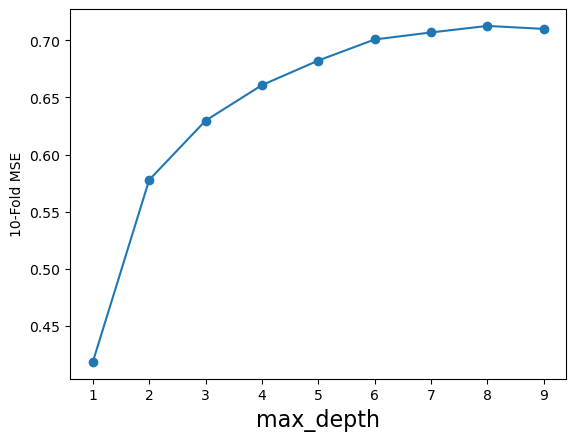

In [27]:
# Modelo 1: Árbol de decisión

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

maxDepth = range(1,10)
param_grid = {'max_depth': maxDepth }
grid = GridSearchCV(DecisionTreeRegressor(random_state=0), param_grid=param_grid, cv = 3, verbose=2)
grid.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth',fontsize=16)
plt.ylabel('10-Fold MSE')

plt.show()

In [28]:
# Resultado modelo 1: Árbol de decisión

maxDepthOptimo = grid.best_params_['max_depth']
treeModel = DecisionTreeRegressor(max_depth=maxDepthOptimo).fit(X_train,y_train)

print("Train: ",treeModel.score(X_train,y_train))
print("Test: ",treeModel.score(X_test,y_test))

Train:  0.7818611705297707
Test:  0.6903252621145156


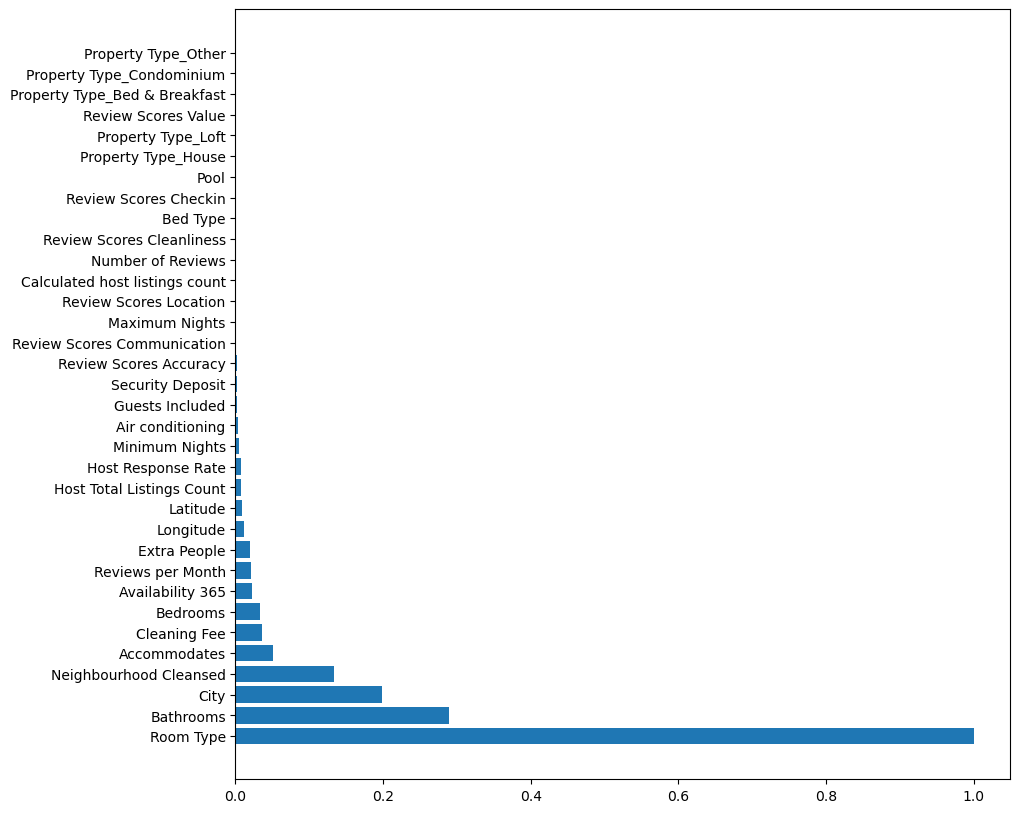

In [29]:
# Importancia de las variables para el modelo 1:

importances = treeModel.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

Fitting 3 folds for each of 14 candidates, totalling 42 fits
[CV] END ........................................max_depth=1; total time=   0.3s
[CV] END ........................................max_depth=1; total time=   0.3s
[CV] END ........................................max_depth=1; total time=   0.3s
[CV] END ........................................max_depth=2; total time=   0.4s
[CV] END ........................................max_depth=2; total time=   0.4s
[CV] END ........................................max_depth=2; total time=   0.4s
[CV] END ........................................max_depth=3; total time=   0.5s
[CV] END ........................................max_depth=3; total time=   0.5s
[CV] END ........................................max_depth=3; total time=   0.5s
[CV] END ........................................max_depth=4; total time=   0.6s
[CV] END ........................................max_depth=4; total time=   0.6s
[CV] END .......................................

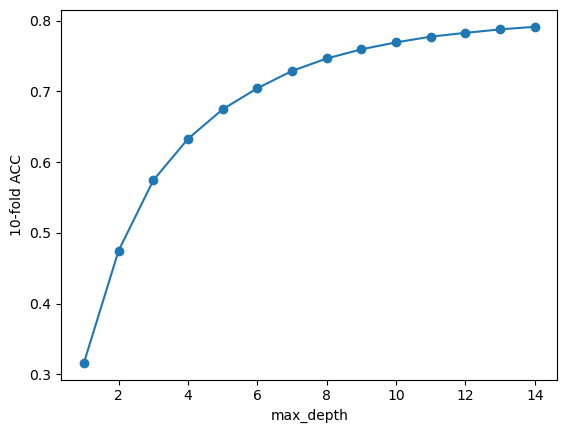

In [30]:
# Modelo 2: Random forest

from sklearn.ensemble import RandomForestRegressor

maxDepth = range(1,15)
tuned_parameters = {'max_depth': maxDepth}

grid = GridSearchCV(RandomForestRegressor(random_state=0, n_estimators=200, max_features='sqrt'), param_grid=tuned_parameters,cv=3, verbose=2) 
grid.fit(X_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth')
plt.ylabel('10-fold ACC')

plt.show()

In [31]:
# Resultados modelo 2: Random forest

maxDepthOptimo = grid.best_params_['max_depth']
randomForest = RandomForestRegressor(max_depth=maxDepthOptimo,n_estimators=200,max_features='sqrt').fit(X_train,y_train)

print("Train: ",randomForest.score(X_train,y_train))
print("Test: ",randomForest.score(X_test,y_test))

Train:  0.9014179503809844
Test:  0.7860505551361795


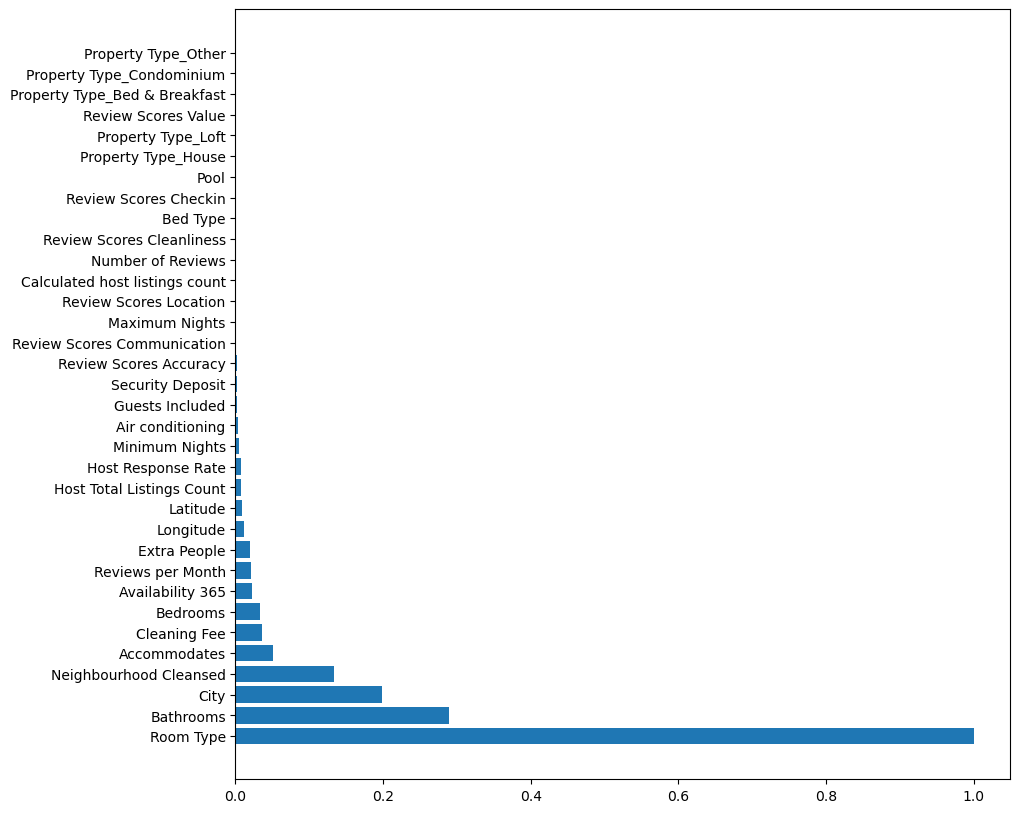

In [32]:
# Importancia de las variables para el modelo 2:

importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

In [33]:
# Cross Validation:
# Aplico Cross Validation y veo la media de los scores

scores = cross_val_score(
    randomForest,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.78940301 0.79754809 0.79737972 0.79601384 0.79022433]
0.794113797055817


In [34]:
# Hago predición con un nuevo dato para comprobar que funciona bien el modelo:

nuevo_dato = pd.DataFrame([{
    'Host Response Rate': 95,
    'Host Total Listings Count': 3,

    'Neighbourhood Cleansed': mean_map['Neighbourhood Cleansed']["la Dreta de l'Eixample"],
    'City': mean_map['City']['Barcelona'],
    'Room Type': mean_map['Room Type']['Entire home/apt'],
    'Bed Type': mean_map['Bed Type']['Real Bed'],

    'Latitude': 41.389683,
    'Longitude': 2.167418,

    'Accommodates': 4,
    'Bathrooms': 2,
    'Bedrooms': 1,

    'Security Deposit': 200,
    'Cleaning Fee': 50,
    'Guests Included': 2,
    'Extra People': 20,
    'Minimum Nights': 2,
    'Maximum Nights': 30,
    'Availability 365': 180,
    'Number of Reviews': 45,

    'Review Scores Accuracy': 5,
    'Review Scores Cleanliness': 3,
    'Review Scores Checkin': 4,
    'Review Scores Communication': 3,
    'Review Scores Location': 5,
    'Review Scores Value': 4,

    'Calculated host listings count': 2,
    'Reviews per Month': 1.5,

    'Air conditioning': 1,
    'Pool': 0,

    'Property Type_Bed & Breakfast': 0,
    'Property Type_Condominium': 1,
    'Property Type_House': 0,
    'Property Type_Loft': 0,
    'Property Type_Other': 0
}])

In [39]:
# Resultado de la predicción:
from sklearn.impute import SimpleImputer

nuevo = nuevo_dato.reindex(columns=X_train.columns, fill_value=0)

imputer = SimpleImputer(strategy='median').fit(X_train)

nuevo = imputer.transform(nuevo)

nuevo = pd.DataFrame(nuevo, columns=X_train.columns)

pred_log = randomForest.predict(nuevo)

precio = np.expm1(pred_log)

print("Predicción log:", pred_log)
print("Precio (€):", precio)

Predicción log: [4.57861339]
Precio (€): [96.37927387]


In [ ]:
# CONCLUSION:

"""
PASOS REALIZADOS PARA ENTRENAR EL MODELO:

1- Importar librerías adecuadas
2- Cargar los datos del fichero base, del cual he separado y guardado en ficheros nuevos los datos de train y test.
3- Con los datos de train, empece con la exploración y limpieza de los datos:
    -Analizar de que tipos son las columnas
    -Observar si tenemos nulos en nuestro target y quitar esas filas.
    -Analizar histogramas de columnas e identificar que columnas pueden ser valiosas para nuestro modelo.
    -He utilizado tecnicas de TargetEncoder poder aprovechar esas columnas de tipo 'object'.
    -También he creado 2 columnas nuevas a partir de 'Amenities' para saber si las casas tenian aire acondicionado o no y
    si tenian piscina. Pienso que esto aporta valor a nuestro modelo.
    - A partir de generar la matriz de correlación de las columnas, he podido decidir que columnas eliminar para prevenir 
    overfitting.
    - Utilice la tenica One-Hot Encoding para la columna 'Property type', la cual nos genera columnas rellenas de ceros y unos,
    y pienso que esto tambien ha permitido sacar información al modelo.
    - Tras mas analisis de los datos, termino borrando mas columnas irrelevantes (en principio) para el modelo.
4- Cargo y aplico los mismos cambios a los datos de test.
5- Observo la distribución de los precios en nuestros datos, la cual tenia un abanico muy amplio y decido aplicar una función 
logaritmica para conseguir una distribución mas uniforme. Posteriormente, a la hora de predecir precios necesito deshacer este cambio.
6- Train/Test Split, para separar nuestro target del resto de los datos.
7- Aplico Lasso, el cual me da un resultado bajo
8- Primero pruebo con un modelo de Arbol de decisión, busco el max_depth óptimo y entro los datos.
Me devuelve un R cuadrado :
-Train:  0.78
-Test:  0.69

9- Luego, pruebo un modelo Random Forest el cual me dio un mejor R cuadrado como resultado:
-Train:  0.90
-Test:  0.78

10- Aplique Cross Validation para comprobar que mis resultados eran correctos y me devuelve un rendimiento de media de 0.794.

Por lo tanto, me quedo con el modelo de Random Forest como el adecuado para realizar la práctica.

11- Para finalizar, creo un dato nuevo para predecir el precio y comprobar que mi modelo realmente predice.
 
"""